# EDGAR Credit Clustering Starter

This notebook pivots the EDGAR fundamentals database into issuer-year credit features and runs **unsupervised clustering**.

Core framing:

- No credit labels at this stage.
- Cluster companies inside comparable sectors/accounting regimes.
- Start with either:
  - `major_sector`: SIC major divisions from the first notebook, or
  - `financial_flag`: Financial vs Non-financial.
- Target: **5 clusters per selected sector group**, then interpret clusters using medians and representative tickers.

In [45]:
import os
import glob
import duckdb
import numpy as np
import pandas as pd

from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

from pathlib import Path
import sys
import joblib

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

In [44]:
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

## 1. Connect to DuckDB

The project reads public EDGAR-derived Parquet files from Cloudflare R2.

No credentials are required.

Remote dataset:
https://pub-a6c3a3e1a0f546beb4be7cc34fd647d1.r2.dev/raw_financial_facts_parquet/

The dataset is split into 401 Parquet files named part_00000.parquet through part_00400.parquet.

Expected local inputs from the previous notebook:

- `financials.duckdb`
- `raw_financial_facts_parquet/*.parquet`
- optionally `03_fundamental_universe_ticker_sic_industry.csv`

In [36]:
DB_PATH = "financials.duckdb"
BASE_URL = "https://pub-a6c3a3e1a0f546beb4be7cc34fd647d1.r2.dev/raw_financial_facts_parquet"

parquet_urls = [
    f"{BASE_URL}/part_{i:05d}.parquet"
    for i in range(401)
]

con = duckdb.connect(DB_PATH)

con.execute("""
INSTALL httpfs;
LOAD httpfs;
""")

con.execute(f"""
CREATE OR REPLACE VIEW raw_facts AS
SELECT *
FROM read_parquet({parquet_urls})
""")

schema = con.execute("DESCRIBE raw_facts").df()
schema


,column_name,column_type,null,key,default,extra
0,concept,VARCHAR,YES,None,None,None
1,label,VARCHAR,YES,None,None,None
2,value,DOUBLE,YES,None,None,None
3,numeric_value,DOUBLE,YES,None,None,None
4,unit,VARCHAR,YES,None,None,None
5,period_type,VARCHAR,YES,None,None,None
6,period_start,VARCHAR,YES,None,None,None
7,period_end,VARCHAR,YES,None,None,None
8,fiscal_year,BIGINT,YES,None,None,None
9,fiscal_period,VARCHAR,YES,None,None,None


In [37]:
summary = con.execute("""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT ticker) AS tickers,
    COUNT(DISTINCT concept) AS concepts,
    MIN(fiscal_year) AS min_year,
    MAX(fiscal_year) AS max_year
FROM raw_facts
""").df()
summary

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,rows,tickers,concepts,min_year,max_year
0,100149899,8194,13256,0,44012


## 2. Sector mapping

The first notebook used SIC major divisions. For clustering, we keep that, but also create a simpler `financial_flag` because financial companies need separate treatment.

In [38]:
def map_sic_major_division(sic):
    if pd.isna(sic):
        return "Unknown"
    try:
        sic = int(float(sic))
    except Exception:
        return "Unknown"

    if 100 <= sic < 1000:
        return "Agriculture"
    if 1000 <= sic < 1500:
        return "Mining / Energy"
    if 1500 <= sic < 1800:
        return "Construction"
    if 2000 <= sic < 4000:
        return "Manufacturing / Industrials"
    if 4000 <= sic < 5000:
        return "Transportation / Utilities"
    if 5000 <= sic < 6000:
        return "Wholesale / Retail"
    if 6000 <= sic < 6800:
        return "Finance / Insurance / Real Estate"
    if 7000 <= sic < 9000:
        return "Services"
    if 9100 <= sic < 9730:
        return "Public Administration"
    return "Other"

def map_financial_flag(sic):
    if pd.isna(sic):
        return "Unknown"
    try:
        sic = int(float(sic))
    except Exception:
        return "Unknown"
    return "Financial" if 6000 <= sic < 6800 else "Non-financial"

In [39]:
# Optional enriched universe from the first notebook.
if os.path.exists(UNIVERSE_CSV):
    universe = pd.read_csv(UNIVERSE_CSV)
    universe["major_sector"] = universe.get("industry", universe["sic"].apply(map_sic_major_division))
    universe["financial_flag"] = universe["sic"].apply(map_financial_flag)
    universe = universe[[c for c in ["ticker", "cik", "name", "sic", "Industry Title", "major_sector", "financial_flag"] if c in universe.columns]].drop_duplicates()
else:
    universe = con.execute("""
    SELECT DISTINCT ticker, cik, company_name AS name, sic
    FROM raw_facts
    WHERE ticker IS NOT NULL
    """).df()
    universe["major_sector"] = universe["sic"].apply(map_sic_major_division)
    universe["financial_flag"] = universe["sic"].apply(map_financial_flag)

universe["major_sector"].value_counts(dropna=False).to_frame("companies")

,companies
major_sector,
Manufacturing / Industrials,2878
Finance / Insurance / Real Estate,1979
Services,1557
Transportation / Utilities,704
Wholesale / Retail,484
Mining / Energy,463
Construction,98
Agriculture,52


In [40]:
universe["financial_flag"].value_counts(dropna=False).to_frame("companies")

,companies
financial_flag,
Non-financial,6236
Financial,1979


## 3. Concept map

EDGAR concepts are noisy. We map multiple possible GAAP concepts into canonical feature names. The query below keeps only target concepts, then aggregates issuer-year-canonical-feature values.

For the first pass, we use **FY periods only** and clean fiscal years to 2020–2025.

In [13]:
CONCEPT_MAP = {
    # Balance sheet
    "assets": ["us-gaap:Assets"],
    "assets_current": ["us-gaap:AssetsCurrent"],
    "liabilities": ["us-gaap:Liabilities"],
    "liabilities_current": ["us-gaap:LiabilitiesCurrent"],
    "cash": [
        "us-gaap:CashAndCashEquivalentsAtCarryingValue",
        "us-gaap:CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents",
        "us-gaap:CashAndDueFromBanks",
    ],
    "receivables": ["us-gaap:AccountsReceivableNetCurrent"],
    "inventory": ["us-gaap:InventoryNet"],
    "ppe": ["us-gaap:PropertyPlantAndEquipmentNet"],
    "goodwill": ["us-gaap:Goodwill"],
    "equity": [
        "us-gaap:StockholdersEquity",
        "us-gaap:StockholdersEquityIncludingPortionAttributableToNoncontrollingInterest",
    ],
    "long_term_debt": ["us-gaap:LongTermDebt", "us-gaap:LongTermDebtNoncurrent"],
    "short_term_debt": [
        "us-gaap:ShortTermBorrowings",
        "us-gaap:LongTermDebtCurrent",
        "us-gaap:CurrentPortionOfLongTermDebt",
    ],

    # Income statement
    "revenue": [
        "us-gaap:Revenues",
        "us-gaap:SalesRevenueNet",
        "us-gaap:RevenueFromContractWithCustomerExcludingAssessedTax",
    ],
    "gross_profit": ["us-gaap:GrossProfit"],
    "operating_income": ["us-gaap:OperatingIncomeLoss"],
    "net_income": ["us-gaap:NetIncomeLoss", "us-gaap:ProfitLoss"],
    "interest_expense": ["us-gaap:InterestExpense", "us-gaap:InterestExpenseNonOperating"],
    "sga": ["us-gaap:SellingGeneralAndAdministrativeExpense"],
    "rd": ["us-gaap:ResearchAndDevelopmentExpense"],

    # Cash flow
    "cfo": ["us-gaap:NetCashProvidedByUsedInOperatingActivities"],
    "capex": ["us-gaap:PaymentsToAcquirePropertyPlantAndEquipment"],
}

concept_lookup = []
for canonical, concepts in CONCEPT_MAP.items():
    for concept in concepts:
        concept_lookup.append({"canonical_feature": canonical, "concept": concept})
concept_lookup = pd.DataFrame(concept_lookup)
concept_lookup.head(20)

,canonical_feature,concept
0,assets,us-gaap:Assets
1,assets_current,us-gaap:AssetsCurrent
2,liabilities,us-gaap:Liabilities
3,liabilities_current,us-gaap:LiabilitiesCurrent
4,cash,us-gaap:CashAndCashEquivalentsAtCarryingValue
5,cash,us-gaap:CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents
6,cash,us-gaap:CashAndDueFromBanks
7,receivables,us-gaap:AccountsReceivableNetCurrent
8,inventory,us-gaap:InventoryNet
9,ppe,us-gaap:PropertyPlantAndEquipmentNet


In [14]:
con.register("concept_lookup", concept_lookup)

# Detect the numeric column used in your raw facts export.
cols = set(schema["column_name"].str.lower())
if "numeric_value" in cols:
    value_col = "numeric_value"
elif "value" in cols:
    value_col = "value"
else:
    raise ValueError("Could not find numeric_value or value column in raw_facts.")

# Pick a filing/period sort column if available. This improves deduplication.
schema_cols = schema["column_name"].tolist()
lower_to_actual = {c.lower(): c for c in schema_cols}
sort_candidates = ["filing_date", "filed", "period_end", "end", "start"]
sort_col = next((lower_to_actual[c] for c in sort_candidates if c in lower_to_actual), None)
print("value_col:", value_col, "| sort_col:", sort_col)

value_col: numeric_value | sort_col: period_end


In [16]:
# We aggregate by median to reduce duplicate filing/noisy restatement impact.
# Later: replace this with a stricter latest-filing selection if the raw columns support it.
con.execute(f"""
CREATE OR REPLACE TABLE issuer_year_facts AS
SELECT
    rf.ticker,
    TRY_CAST(rf.cik AS VARCHAR) AS cik,
    ANY_VALUE(rf.company_name) AS company_name,
    TRY_CAST(rf.sic AS INTEGER) AS sic,
    TRY_CAST(rf.fiscal_year AS INTEGER) AS fiscal_year,
    cl.canonical_feature,
    MEDIAN(TRY_CAST(rf.{value_col} AS DOUBLE)) AS value
FROM raw_facts rf
JOIN concept_lookup cl
    ON rf.concept = cl.concept
WHERE TRY_CAST(rf.fiscal_year AS INTEGER) BETWEEN 2020 AND 2025
  AND rf.fiscal_period = 'FY'
  AND TRY_CAST(rf.{value_col} AS DOUBLE) IS NOT NULL
GROUP BY 1,2,4,5,6
""")

facts_summary = con.execute("""
SELECT
    canonical_feature,
    COUNT(*) AS row_count,
    COUNT(DISTINCT ticker) AS ticker_count
FROM issuer_year_facts
GROUP BY canonical_feature
ORDER BY ticker_count DESC
""").df()

facts_summary

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,canonical_feature,row_count,ticker_count
0,net_income,36055,7171
1,assets,36044,7147
2,cfo,35527,7106
3,equity,35594,7048
4,cash,34942,7035
5,liabilities,31638,6462
6,revenue,27296,5841
7,operating_income,27902,5778
8,ppe,26720,5771
9,liabilities_current,27656,5673


## 4. Build issuer-year panel

One row per ticker-year. Then attach sector labels.

In [17]:
panel = con.execute("""
PIVOT issuer_year_facts
ON canonical_feature
USING MAX(value)
GROUP BY ticker, cik, company_name, sic, fiscal_year
""").df()

panel["major_sector"] = panel["sic"].apply(map_sic_major_division)
panel["financial_flag"] = panel["sic"].apply(map_financial_flag)

panel.shape, panel.head()

((36288, 28),
   ticker      cik                        company_name   sic  fiscal_year  \
 0   PTCT  1070081              PTC THERAPEUTICS, INC.  2834         2024   
 1    CUE  1645460                 Cue Biopharma, Inc.  2834         2023   
 2   FRSX  1691221  Foresight Autonomous Holdings Ltd.  7372         2025   
 3   TLRY  1731348                 Tilray Brands, Inc.  2833         2024   
 4   KTCC   719733                     KEY TRONIC CORP  3672         2024   
 
          assets  assets_current       capex         cash          cfo  \
 0  1.800361e+09    1.292080e+09  28438000.0  602142500.0 -158418000.0   
 1  7.640650e+07    6.432050e+07     85500.0   50064000.0  -40883500.0   
 2  9.049000e+06    7.338500e+06     62000.0    7132000.0  -11055000.0   
 3  4.264462e+09    7.253695e+08         NaN  217486000.0  -30905000.0   
 4  3.822565e+08    3.157200e+08   6813000.0    3588500.0   -4907000.0   
 
          equity      goodwill  gross_profit  interest_expense    inventory 

In [ ]:
panel.groupby(["major_sector", "fiscal_year"]).size().unstack(fill_value=0)

## 5. Credit feature engineering

The feature set has two layers:

1. Universal features usable for most companies.
2. Non-financial-only features where working capital, debt, capex, and interest coverage are more meaningful.

Financials should not be forced into industrial ratios like current ratio or debt/assets without sector-specific accounting logic.

In [18]:
def safe_div(n, d, min_abs_denominator=None):
    """Division helper that returns NaN when denominator is zero, tiny, or missing."""
    n = pd.to_numeric(n, errors="coerce")
    d = pd.to_numeric(d, errors="coerce")
    d_safe = d.copy()
    d_safe = d_safe.mask(d_safe == 0)
    if min_abs_denominator is not None:
        d_safe = d_safe.mask(d_safe.abs() < min_abs_denominator)
    out = n / d_safe
    return out.replace([np.inf, -np.inf], np.nan)

for c in CONCEPT_MAP.keys():
    if c not in panel.columns:
        panel[c] = np.nan

panel["total_debt"] = panel["long_term_debt"].fillna(0) + panel["short_term_debt"].fillna(0)
panel.loc[panel[["long_term_debt", "short_term_debt"]].isna().all(axis=1), "total_debt"] = np.nan
panel["fcf"] = panel["cfo"] - panel["capex"].abs()

# Denominator-safe ratio engineering.
# The min_abs_denominator thresholds prevent tiny denominators from creating fake extreme clusters.
panel["log_assets"] = np.log1p(panel["assets"].clip(lower=0))

# Universal-ish scale and solvency ratios.
panel["liabilities_to_assets"] = safe_div(panel["liabilities"], panel["assets"], 10_000_000)
panel["equity_to_assets"] = safe_div(panel["equity"], panel["assets"], 10_000_000)
panel["cash_to_assets"] = safe_div(panel["cash"], panel["assets"], 10_000_000)
panel["revenue_to_assets"] = safe_div(panel["revenue"], panel["assets"], 10_000_000)
panel["net_income_to_assets"] = safe_div(panel["net_income"], panel["assets"], 10_000_000)
panel["cfo_to_assets"] = safe_div(panel["cfo"], panel["assets"], 10_000_000)

# Industrial / non-financial ratios.
panel["debt_to_assets"] = safe_div(panel["total_debt"], panel["assets"], 10_000_000)
panel["debt_to_equity"] = safe_div(panel["total_debt"], panel["equity"], 10_000_000)
panel["current_ratio"] = safe_div(panel["assets_current"], panel["liabilities_current"], 1_000_000)
panel["quick_ratio"] = safe_div(
    panel["cash"].fillna(0) + panel["receivables"].fillna(0),
    panel["liabilities_current"],
    1_000_000,
)
panel.loc[panel[["cash", "receivables"]].isna().all(axis=1), "quick_ratio"] = np.nan

# These are useful diagnostics, but too unstable for first-pass KMeans.
panel["gross_margin"] = safe_div(panel["gross_profit"], panel["revenue"], 10_000_000)
panel["operating_margin"] = safe_div(panel["operating_income"], panel["revenue"], 10_000_000)
panel["interest_coverage"] = safe_div(panel["operating_income"], panel["interest_expense"].abs(), 1_000_000)
panel["cfo_to_liabilities"] = safe_div(panel["cfo"], panel["liabilities"], 10_000_000)
panel["fcf_to_debt"] = safe_div(panel["fcf"], panel["total_debt"], 1_000_000)
panel["capex_to_revenue"] = safe_div(panel["capex"].abs(), panel["revenue"], 10_000_000)

ratio_cols = [
    "liabilities_to_assets", "equity_to_assets", "cash_to_assets", "revenue_to_assets",
    "net_income_to_assets", "cfo_to_assets", "debt_to_assets", "debt_to_equity",
    "current_ratio", "quick_ratio", "gross_margin", "operating_margin", "interest_coverage",
    "cfo_to_liabilities", "fcf_to_debt", "capex_to_revenue"
]

# Keep a clean modeling frame separate from raw panel.
model_df = panel.copy()

# Hard filters to remove tiny shells and obviously broken accounting geometry.
model_df = model_df[(model_df["assets"].notna()) & (model_df["assets"] >= 10_000_000)].copy()

hard_filters = {
    "liabilities_to_assets": (-1, 3),
    "equity_to_assets": (-3, 3),
    "net_income_to_assets": (-2, 2),
    "cfo_to_assets": (-2, 2),
    "revenue_to_assets": (0, 10),
}

for col, (lo, hi) in hard_filters.items():
    if col in model_df.columns:
        model_df = model_df[model_df[col].between(lo, hi) | model_df[col].isna()].copy()

# Winsorize only the relatively stable ratios used for clustering.
winsor_caps = {
    "liabilities_to_assets": (-1, 3),
    "debt_to_assets": (0, 2),
    "debt_to_equity": (-5, 5),
    "equity_to_assets": (-2, 2),
    "cash_to_assets": (0, 2),
    "net_income_to_assets": (-1, 1),
    "cfo_to_assets": (-1, 1),
    "revenue_to_assets": (0, 5),
    "current_ratio": (0, 10),
    "quick_ratio": (0, 10),
}

for col, (lo, hi) in winsor_caps.items():
    if col in model_df.columns:
        model_df[col] = model_df[col].clip(lower=lo, upper=hi)

print("Raw panel rows:", len(panel))
print("Model rows after filters:", len(model_df))
print("Rows removed:", len(panel) - len(model_df))

model_df[["ticker", "fiscal_year", "major_sector", "financial_flag", "log_assets"] + ratio_cols].head()



Raw panel rows: 36288
Model rows after filters: 31558
Rows removed: 4730


,ticker,fiscal_year,major_sector,financial_flag,log_assets,liabilities_to_assets,equity_to_assets,cash_to_assets,revenue_to_assets,net_income_to_assets,cfo_to_assets,debt_to_assets,debt_to_equity,current_ratio,quick_ratio,gross_margin,operating_margin,interest_coverage,cfo_to_liabilities,fcf_to_debt,capex_to_revenue
0,PTCT,2024,Manufacturing / Industrials,Non-financial,21.311253,1.532289,-0.323724,0.334457,0.448121,-0.310503,-0.087992,0.158197,-0.488680,2.182418,1.017063,NaN,-0.544761,NaN,-0.057425,-0.656067,0.035249
1,CUE,2023,Manufacturing / Industrials,Non-financial,18.151578,0.327498,0.857152,0.655232,0.044073,-0.678889,-0.535079,0.081413,0.094981,4.493381,3.558734,NaN,NaN,NaN,-1.633837,-6.586127,NaN
3,TLRY,2024,Manufacturing / Industrials,Non-financial,22.173582,0.205865,0.807380,0.051000,0.147351,-0.106805,-0.007247,0.004856,0.006014,1.981481,0.850775,0.233874,-0.971401,-13.095362,-0.035203,NaN,NaN
4,KTCC,2024,Manufacturing / Industrials,Non-financial,19.761602,0.663908,0.331707,0.009388,0.372595,0.002532,-0.012837,0.316605,0.954474,2.511794,0.028549,0.080799,0.023598,NaN,-0.019335,-0.096840,0.047835
5,BBAAY,2020,Services,Non-financial,27.595473,0.362328,0.481151,0.196851,0.324902,0.074775,0.143398,NaN,NaN,1.301460,0.995596,NaN,0.201556,14.452092,0.395769,NaN,NaN


In [19]:
feature_coverage = (
    panel[["financial_flag", "major_sector"] + ["log_assets"] + ratio_cols]
    .groupby(["financial_flag", "major_sector"])
    .agg(lambda s: s.notna().mean())
)
feature_coverage.round(2)

log_assets  \
financial_flag major_sector                                    
Financial      Finance / Insurance / Real Estate        0.99   
Non-financial  Agriculture                              0.99   
               Construction                             1.00   
               Manufacturing / Industrials              1.00   
               Mining / Energy                          0.98   
               Services                                 0.99   
               Transportation / Utilities               1.00   
               Wholesale / Retail                       0.99   

                                                  liabilities_to_assets  \
financial_flag major_sector                                               
Financial      Finance / Insurance / Real Estate                   0.95   
Non-financial  Agriculture                                         0.66   
               Construction                                        0.78   
               Manufacturing / Industrials                         0.74   
               Mining / Energy                                     0.62   
               Services                                            0.73   
               Transportation / Utilities                          0.56   
               Wholesale / Retail                                  0.67   

                                                  equity_to_assets  \
financial_flag major_sector                                          
Financial      Finance / Insurance / Real Estate              0.93   
Non-financial  Agriculture                                    0.75   
               Construction                                   0.89   
               Manufacturing / Industrials                    0.86   
               Mining / Energy                                0.71   
               Services                                       0.80   
               Transportation / Utilities                     0.89   
               Wholesale / Retail                             0.85   

                                                  cash_to_assets  \
financial_flag major_sector                                        
Financial      Finance / Insurance / Real Estate            0.93   
Non-financial  Agriculture                                  0.76   
               Construction                                 0.85   
               Manufacturing / Industrials                  0.85   
               Mining / Energy                              0.73   
               Services                                     0.79   
               Transportation / Utilities                   0.93   
               Wholesale / Retail                           0.83   

                                                  revenue_to_assets  \
financial_flag major_sector                                           
Financial      Finance / Insurance / Real Estate               0.57   
Non-financial  Agriculture                                     0.72   
               Construction                                    0.79   
               Manufacturing / Industrials                     0.68   
               Mining / Energy                                 0.56   
               Services                                        0.70   
               Transportation / Utilities                      0.81   
               Wholesale / Retail                              0.80   

                                                  net_income_to_assets  \
financial_flag major_sector                                              
Financial      Finance / Insurance / Real Estate                  0.95   
Non-financial  Agriculture                                        0.76   
               Construction                                       0.88   
               Manufacturing / Industrials                        0.86   
               Mining / Energy                                    0.74   
               Services                        

## 6. Decide clustering segmentation

Default recommendation:

- First run `financial_flag`: Financial vs Non-financial.
- Then run `major_sector` for non-financial sectors with enough companies.
- Keep 5 clusters only where the group has enough observations. A practical floor is 100 issuer-years, preferably 200+.

In [20]:
SEGMENT_COL = "financial_flag"   # alternatives: "major_sector"
N_CLUSTERS = 5
MIN_ROWS_PER_SEGMENT = 500

# First-pass stable feature set. Keep volatile denominator-sensitive ratios for interpretation only.
UNIVERSAL_FEATURES = [
    "log_assets",
    "liabilities_to_assets",
    "equity_to_assets",
    "cash_to_assets",
    "revenue_to_assets",
    "net_income_to_assets",
    "cfo_to_assets",
]

NONFIN_FEATURES = UNIVERSAL_FEATURES + [
    "debt_to_assets",
    "current_ratio",
    "quick_ratio",
]

FIN_FEATURES = [
    "log_assets",
    "liabilities_to_assets",
    "equity_to_assets",
    "cash_to_assets",
    "revenue_to_assets",
    "net_income_to_assets",
    "cfo_to_assets",
]

FEATURES_BY_FIN_FLAG = {
    "Financial": FIN_FEATURES,
    "Non-financial": NONFIN_FEATURES,
    "Unknown": UNIVERSAL_FEATURES,
}



In [46]:
def get_features_for_segment(segment_name, segment_col):
    if segment_col == "financial_flag":
        return FEATURES_BY_FIN_FLAG.get(segment_name, UNIVERSAL_FEATURES)
    # For major sectors, treat Finance / Insurance / Real Estate with financial features.
    if segment_name == "Finance / Insurance / Real Estate":
        return FIN_FEATURES
    return NONFIN_FEATURES


def cluster_segment(df, segment_name, segment_col, n_clusters=5, min_rows=500):
    features = get_features_for_segment(segment_name, segment_col)
    use = df[df[segment_col] == segment_name].copy()
    use = use.dropna(subset=["ticker", "fiscal_year"])

    # Keep features with at least 50% availability inside this segment.
    availability = use[features].notna().mean().sort_values(ascending=False)
    features = availability[availability >= 0.50].index.tolist()

    if len(use) < min_rows or len(features) < 4:
        metrics = {
            "segment": segment_name,
            "status": "skipped",
            "rows": len(use),
            "features": len(features),
            "feature_list": features,
            "silhouette": np.nan,
            "calinski_harabasz": np.nan,
            "davies_bouldin": np.nan,
        }
        return None, metrics, None

    X = use[features]

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
        ("cluster", KMeans(
            n_clusters=n_clusters,
            init="k-means++",
            n_init=500,
            random_state=42
        )),
    ])

    labels = pipe.fit_predict(X)

    use["cluster"] = labels
    use["cluster_key"] = (
        use[segment_col].astype(str) + "__" + use["cluster"].astype(str)
    )

    Xt = pipe[:-1].transform(X)

    metrics = {
        "segment": segment_name,
        "status": "clustered",
        "rows": len(use),
        "features": len(features),
        "feature_list": features,
        "silhouette": silhouette_score(Xt, labels) if len(set(labels)) > 1 else np.nan,
        "calinski_harabasz": calinski_harabasz_score(Xt, labels) if len(set(labels)) > 1 else np.nan,
        "davies_bouldin": davies_bouldin_score(Xt, labels) if len(set(labels)) > 1 else np.nan,
    }

    profile_cols = [
        c for c in [
            "log_assets",
            "liabilities_to_assets",
            "debt_to_assets",
            "equity_to_assets",
            "current_ratio",
            "quick_ratio",
            "cash_to_assets",
            "net_income_to_assets",
            "cfo_to_assets",
            "revenue_to_assets",
            "interest_coverage",
            "fcf_to_debt",
            "operating_margin",
            "gross_margin",
        ]
        if c in use.columns
    ]

    cluster_profile = (
        use
        .groupby("cluster")[profile_cols]
        .median()
        .round(6)
    )

    cluster_sizes = (
        use
        .groupby("cluster")
        .agg(
            issuer_years=("ticker", "size"),
            issuers=("ticker", "nunique"),
        )
        .reset_index()
    )

    model_artifact = {
        "segment_name": segment_name,
        "segment_col": segment_col,
        "n_clusters": n_clusters,
        "pipeline": pipe,
        "feature_cols": features,
        "availability": availability.to_dict(),
        "metrics": metrics,
        "cluster_profile": cluster_profile,
        "cluster_sizes": cluster_sizes,
    }

    return use, metrics, model_artifact

clustered_parts = []
metrics = []
segment_artifacts = {}

for segment_name in sorted(model_df[SEGMENT_COL].dropna().unique()):
    clustered, m, artifact = cluster_segment(
        model_df,
        segment_name,
        SEGMENT_COL,
        N_CLUSTERS,
        MIN_ROWS_PER_SEGMENT
    )

    metrics.append(m)

    if clustered is not None:
        clustered_parts.append(clustered)

    if artifact is not None:
        segment_artifacts[segment_name] = artifact

metrics_df = pd.DataFrame(metrics)

clustered_panel = (
    pd.concat(clustered_parts, ignore_index=True)
    if clustered_parts
    else pd.DataFrame()
)

metrics_df


,segment,status,rows,features,feature_list,silhouette,calinski_harabasz,davies_bouldin
0,Financial,clustered,9036,7,"[log_assets, net_income_to_assets, liabilities_to_assets, cfo_to_assets, equity_to_assets, cash_to_assets, revenue_t...",0.739948,5352.439353,0.702834
1,Non-financial,clustered,22522,10,"[log_assets, net_income_to_assets, equity_to_assets, cfo_to_assets, cash_to_assets, current_ratio, quick_ratio, reve...",0.219132,6199.386585,1.271905


In [47]:
clustered_panel = pd.concat(clustered_parts, ignore_index=True) if clustered_parts else pd.DataFrame()
clustered_panel.shape

(31558, 49)

In [48]:
# Cluster balance check. If one cluster still contains >90% of a segment, the model is still mostly separating outliers.
cluster_size_check = (
    clustered_panel
    .groupby([SEGMENT_COL, "cluster"])
    .size()
    .reset_index(name="row_count")
    .sort_values([SEGMENT_COL, "row_count"], ascending=[True, False])
)

cluster_size_check



,financial_flag,cluster,row_count
0,Financial,0,8285
4,Financial,4,333
2,Financial,2,292
3,Financial,3,70
1,Financial,1,56
5,Non-financial,0,12800
6,Non-financial,1,4390
7,Non-financial,2,2556
8,Non-financial,3,2149
9,Non-financial,4,627


## 7. Interpret clusters

Clusters only become useful after interpretation. We rank them by stress indicators:

- higher liabilities/assets and debt/assets = worse
- lower equity/assets, cash/assets, coverage, CFO/assets = worse
- lower profitability = worse

This ranking is not a credit rating. It is a practical credit-risk ordering for analyst review.

In [49]:
INTERPRET_FEATURES = [
    "log_assets", "liabilities_to_assets", "equity_to_assets", "cash_to_assets",
    "net_income_to_assets", "cfo_to_assets", "debt_to_assets", "current_ratio",
    "quick_ratio", "revenue_to_assets", "interest_coverage", "cfo_to_liabilities",
    "fcf_to_debt", "operating_margin", "gross_margin"
]
INTERPRET_FEATURES = [c for c in INTERPRET_FEATURES if c in clustered_panel.columns]

cluster_profile = (
    clustered_panel
    .groupby([SEGMENT_COL, "cluster"])
    .agg(
        issuer_years=("ticker", "size"),
        issuers=("ticker", "nunique"),
        **{f"median_{c}": (c, "median") for c in INTERPRET_FEATURES}
    )
    .reset_index()
    .sort_values([SEGMENT_COL, "issuer_years"], ascending=[True, False])
)
cluster_profile



,financial_flag,cluster,issuer_years,issuers,median_log_assets,median_liabilities_to_assets,median_equity_to_assets,median_cash_to_assets,median_net_income_to_assets,median_cfo_to_assets,median_debt_to_assets,median_current_ratio,median_quick_ratio,median_revenue_to_assets,median_interest_coverage,median_cfo_to_liabilities,median_fcf_to_debt,median_operating_margin,median_gross_margin
0,Financial,0,8285,1630,22.580738,0.848197,0.130597,0.032534,0.008850,0.014953,0.102243,1.651610,0.692105,0.085148,1.647809,0.017378,0.258240,0.174750,0.592705
4,Financial,4,333,105,20.950124,0.623949,0.333728,0.168394,0.040369,0.093163,0.228692,1.669906,0.835574,0.966822,2.682707,0.141467,0.298413,0.049753,0.235588
2,Financial,2,292,133,19.141026,0.230662,0.637631,0.222609,-0.312504,-0.142779,0.217120,1.254058,0.407148,0.193248,-7.604046,-0.261659,-0.400244,-0.727381,0.233820
3,Financial,3,70,42,17.412101,0.638142,0.334126,0.091408,-0.939090,-0.313352,0.223467,0.945621,0.246666,0.281513,-7.920119,-0.265212,-3.472338,-0.869560,0.237080
1,Financial,1,56,23,20.079617,0.734053,0.244229,0.230774,-0.106181,-0.001137,0.113907,1.395288,0.792076,3.386407,-47.141689,0.006872,-0.003801,-0.050109,0.054926
5,Non-financial,0,12800,3346,20.708770,0.448297,0.437231,0.089220,0.017168,0.058572,0.137264,1.812749,0.887612,0.596146,3.471925,0.107606,0.222689,0.047833,0.355828
6,Non-financial,1,4390,1319,22.293856,0.718293,0.269052,0.049385,0.018169,0.063904,0.433864,1.241898,0.614642,0.401192,1.909767,0.085930,0.070206,0.112611,0.354351
7,Non-financial,2,2556,1056,17.780733,0.456748,0.477974,0.296250,-0.622215,-0.439934,0.155885,3.017638,1.527099,0.174679,-13.406070,-0.814410,-2.309407,-1.157503,0.354468
8,Non-financial,3,2149,818,19.027498,0.133207,0.732063,0.468478,-0.215298,-0.180003,0.060118,10.000000,5.926631,0.111362,-17.829566,-0.963714,-1.759800,-0.372055,0.502796
9,Non-financial,4,627,265,20.551500,1.149409,-0.162828,0.091272,-0.045215,0.024459,0.886611,1.350187,0.699842,0.536353,0.381669,0.019576,0.000884,0.024021,0.372789


In [50]:
profile_cols = [
    c for c in [
        "log_assets",
        "liabilities_to_assets",
        "debt_to_assets",
        "equity_to_assets",
        "current_ratio",
        "quick_ratio",
        "cash_to_assets",
        "net_income_to_assets",
        "cfo_to_assets",
        "revenue_to_assets",
        "interest_coverage",
        "fcf_to_debt",
        "operating_margin",
        "gross_margin",
    ]
    if c in clustered_panel.columns
]

cluster_medians = (
    clustered_panel
    .groupby([SEGMENT_COL, "cluster"])[profile_cols]
    .median()
    .round(3)
)

cluster_medians

log_assets  liabilities_to_assets  debt_to_assets  \
financial_flag cluster                                                      
Financial      0            22.581                  0.848           0.102   
               1            20.080                  0.734           0.114   
               2            19.141                  0.231           0.217   
               3            17.412                  0.638           0.223   
               4            20.950                  0.624           0.229   
Non-financial  0            20.709                  0.448           0.137   
               1            22.294                  0.718           0.434   
               2            17.781                  0.457           0.156   
               3            19.027                  0.133           0.060   
               4            20.552                  1.149           0.887   

                        equity_to_assets  current_ratio  quick_ratio  \
financial_flag cluster                                                 
Financial      0                   0.131          1.652        0.692   
               1                   0.244          1.395        0.792   
               2                   0.638          1.254        0.407   
               3                   0.334          0.946        0.247   
               4                   0.334          1.670        0.836   
Non-financial  0                   0.437          1.813        0.888   
               1                   0.269          1.242        0.615   
               2                   0.478          3.018        1.527   
               3                   0.732         10.000        5.927   
               4                  -0.163          1.350        0.700   

                        cash_to_assets  net_income_to_assets  cfo_to_assets  \
financial_flag cluster                                                        
Financial      0                 0.033                 0.009          0.015   
               1                 0.231                -0.106         -0.001   
               2                 0.223                -0.313         -0.143   
               3                 0.091                -0.939         -0.313   
               4                 0.168                 0.040          0.093   
Non-financial  0                 0.089                 0.017          0.059   
               1                 0.049                 0.018          0.064   
               2                 0.296                -0.622         -0.440   
               3                 0.468                -0.215         -0.180   
               4                 0.091                -0.045          0.024   

                        revenue_to_assets  interest_coverage  fcf_to_debt  \
financial_flag cluster                                                      
Financial      0                    0.085              1.648        0.258   
               1                    3.386            -47.142       -0.004   
               2                    0.193             -7.604       -0.400   
               3                    0.282             -7.920       -3.472   
               4                    0.967              2.683        0.298   
Non-financial  0                    0.596              3.472        0.223   
               1                    0.401              1.910        0.070   
               2                    0.175            -13.406       -2.309   
               3                    0.111            -17.830       -1.760   
               4                    0.536              0.382        0.001   

                        operating_margin  gross_margin  
financial_flag cluster                                  
Financial      0                   0.175         0.593  
               1                  -0.050         0.055  
               2                  -0.727         0.234  
               3                  -0.870         0.237  
               4  

In [51]:
feature_extremes = (
    clustered_panel[profile_cols]
    .quantile([0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999])
    .T
    .round(3)
)

feature_extremes

,0.001,0.010,0.050,0.500,0.950,0.990,0.999
log_assets,16.139,16.306,16.931,21.098,25.765,28.782,31.504
liabilities_to_assets,0.000,0.009,0.066,0.576,1.019,1.555,2.574
debt_to_assets,0.000,0.000,0.005,0.222,0.786,1.149,2.000
equity_to_assets,-1.926,-0.759,-0.102,0.333,0.861,1.070,1.361
current_ratio,0.009,0.137,0.505,1.880,10.000,10.000,10.000
quick_ratio,0.000,0.011,0.078,0.947,6.003,10.000,10.000
cash_to_assets,0.000,0.000,0.004,0.076,0.587,0.915,1.224
net_income_to_assets,-1.000,-1.000,-0.611,0.007,0.123,0.227,0.575
cfo_to_assets,-1.000,-0.888,-0.443,0.024,0.176,0.281,0.557
revenue_to_assets,0.000,0.000,0.010,0.359,1.678,2.985,5.000


In [52]:
industry_cluster_mix = (
    clustered_panel
    .groupby([SEGMENT_COL, "cluster", "major_sector"])
    .size()
    .reset_index(name="row_count")
)

industry_cluster_mix["cluster_total"] = (
    industry_cluster_mix
    .groupby([SEGMENT_COL, "cluster"])["row_count"]
    .transform("sum")
)

industry_cluster_mix["pct_of_cluster"] = (
    industry_cluster_mix["row_count"] / industry_cluster_mix["cluster_total"]
)

industry_cluster_mix = (
    industry_cluster_mix
    .sort_values([SEGMENT_COL, "cluster", "pct_of_cluster"], ascending=[True, True, False])
)

industry_cluster_mix.head(50)

,financial_flag,cluster,major_sector,row_count,cluster_total,pct_of_cluster
0,Financial,0,Finance / Insurance / Real Estate,8285,8285,1.000000
1,Financial,1,Finance / Insurance / Real Estate,56,56,1.000000
2,Financial,2,Finance / Insurance / Real Estate,292,292,1.000000
3,Financial,3,Finance / Insurance / Real Estate,70,70,1.000000
4,Financial,4,Finance / Insurance / Real Estate,333,333,1.000000
7,Non-financial,0,Manufacturing / Industrials,5744,12800,0.448750
9,Non-financial,0,Services,3429,12800,0.267891
11,Non-financial,0,Wholesale / Retail,1485,12800,0.116016
10,Non-financial,0,Transportation / Utilities,1096,12800,0.085625
8,Non-financial,0,Mining / Energy,667,12800,0.052109


In [53]:
def add_credit_stress_score(profile):
    p = profile.copy()
    score = 0

    # Bad when high
    for c in ["median_liabilities_to_assets", "median_debt_to_assets"]:
        if c in p.columns:
            score += p.groupby(SEGMENT_COL)[c].rank(pct=True)

    # Bad when low
    for c in [
        "median_equity_to_assets", "median_cash_to_assets", "median_net_income_to_assets",
        "median_cfo_to_assets", "median_current_ratio", "median_interest_coverage",
        "median_cfo_to_liabilities", "median_fcf_to_debt", "median_operating_margin"
    ]:
        if c in p.columns:
            score += 1 - p.groupby(SEGMENT_COL)[c].rank(pct=True)

    p["credit_stress_score"] = score
    p["stress_rank_within_segment"] = p.groupby(SEGMENT_COL)["credit_stress_score"].rank(ascending=False, method="dense").astype(int)
    return p.sort_values([SEGMENT_COL, "stress_rank_within_segment"])

cluster_profile_ranked = add_credit_stress_score(cluster_profile)
cluster_profile_ranked

,financial_flag,cluster,issuer_years,issuers,median_log_assets,median_liabilities_to_assets,median_equity_to_assets,median_cash_to_assets,median_net_income_to_assets,median_cfo_to_assets,median_debt_to_assets,median_current_ratio,median_quick_ratio,median_revenue_to_assets,median_interest_coverage,median_cfo_to_liabilities,median_fcf_to_debt,median_operating_margin,median_gross_margin,credit_stress_score,stress_rank_within_segment
3,Financial,3,70,42,17.412101,0.638142,0.334126,0.091408,-0.939090,-0.313352,0.223467,0.945621,0.246666,0.281513,-7.920119,-0.265212,-3.472338,-0.869560,0.237080,7.6,1
1,Financial,1,56,23,20.079617,0.734053,0.244229,0.230774,-0.106181,-0.001137,0.113907,1.395288,0.792076,3.386407,-47.141689,0.006872,-0.003801,-0.050109,0.054926,5.0,2
2,Financial,2,292,133,19.141026,0.230662,0.637631,0.222609,-0.312504,-0.142779,0.217120,1.254058,0.407148,0.193248,-7.604046,-0.261659,-0.400244,-0.727381,0.233820,5.0,3
0,Financial,0,8285,1630,22.580738,0.848197,0.130597,0.032534,0.008850,0.014953,0.102243,1.651610,0.692105,0.085148,1.647809,0.017378,0.258240,0.174750,0.592705,4.0,4
4,Financial,4,333,105,20.950124,0.623949,0.333728,0.168394,0.040369,0.093163,0.228692,1.669906,0.835574,0.966822,2.682707,0.141467,0.298413,0.049753,0.235588,2.4,5
9,Non-financial,4,627,265,20.551500,1.149409,-0.162828,0.091272,-0.045215,0.024459,0.886611,1.350187,0.699842,0.536353,0.381669,0.019576,0.000884,0.024021,0.372789,6.2,1
7,Non-financial,2,2556,1056,17.780733,0.456748,0.477974,0.296250,-0.622215,-0.439934,0.155885,3.017638,1.527099,0.174679,-13.406070,-0.814410,-2.309407,-1.157503,0.354468,6.2,2
6,Non-financial,1,4390,1319,22.293856,0.718293,0.269052,0.049385,0.018169,0.063904,0.433864,1.241898,0.614642,0.401192,1.909767,0.085930,0.070206,0.112611,0.354351,4.4,3
8,Non-financial,3,2149,818,19.027498,0.133207,0.732063,0.468478,-0.215298,-0.180003,0.060118,10.000000,5.926631,0.111362,-17.829566,-0.963714,-1.759800,-0.372055,0.502796,4.4,3
5,Non-financial,0,12800,3346,20.708770,0.448297,0.437231,0.089220,0.017168,0.058572,0.137264,1.812749,0.887612,0.596146,3.471925,0.107606,0.222689,0.047833,0.355828,2.8,4


In [54]:
# Representative tickers closest to each cluster centroid approximation using median feature distance.
def representatives(clustered_panel, segment_col, max_names=10):
    rows = []
    for (seg, cl), g in clustered_panel.groupby([segment_col, "cluster"]):
        features = get_features_for_segment(seg, segment_col)
        features = [f for f in features if f in g.columns and g[f].notna().mean() >= 0.50]
        if not features:
            continue
        med = g[features].median(numeric_only=True)
        X = g[features].copy()
        X = X.fillna(med)
        dist = ((X - med) ** 2).sum(axis=1) ** 0.5
        reps = g.loc[dist.sort_values().index, ["ticker", "company_name", "fiscal_year"]].head(max_names)
        rows.append({
            segment_col: seg,
            "cluster": cl,
            "representative_tickers": ", ".join(reps["ticker"].astype(str).unique()[:max_names]),
            "sample_companies": " | ".join(reps["company_name"].dropna().astype(str).unique()[:5]),
        })
    return pd.DataFrame(rows)

cluster_representatives = representatives(clustered_panel, SEGMENT_COL)
cluster_profile_ranked.merge(cluster_representatives, on=[SEGMENT_COL, "cluster"], how="left")

,financial_flag,cluster,issuer_years,issuers,median_log_assets,median_liabilities_to_assets,median_equity_to_assets,median_cash_to_assets,median_net_income_to_assets,median_cfo_to_assets,median_debt_to_assets,median_current_ratio,median_quick_ratio,median_revenue_to_assets,median_interest_coverage,median_cfo_to_liabilities,median_fcf_to_debt,median_operating_margin,median_gross_margin,credit_stress_score,stress_rank_within_segment,representative_tickers,sample_companies
0,Financial,3,70,42,17.412101,0.638142,0.334126,0.091408,-0.939090,-0.313352,0.223467,0.945621,0.246666,0.281513,-7.920119,-0.265212,-3.472338,-0.869560,0.237080,7.6,1,"TONX, SHFS, SHFSW, AIXC, GLAE, ORBS, AVX","TON Strategy Co | SHF Holdings, Inc. | AIxCrypto Holdings, Inc. | GlassBridge Enterprises, Inc. | Eightco Holdings Inc."
1,Financial,1,56,23,20.079617,0.734053,0.244229,0.230774,-0.106181,-0.001137,0.113907,1.395288,0.792076,3.386407,-47.141689,0.006872,-0.003801,-0.050109,0.054926,5.0,2,"OPADW, OPAD, ALHC, CLOV, CCGWW, CCG, BKKT","Offerpad Solutions Inc. | Alignment Healthcare, Inc. | CLOVER HEALTH INVESTMENTS, CORP. /DE | Cheche Group Inc. | Ba..."
2,Financial,2,292,133,19.141026,0.230662,0.637631,0.222609,-0.312504,-0.142779,0.217120,1.254058,0.407148,0.193248,-7.604046,-0.261659,-0.400244,-0.727381,0.233820,5.0,3,"SLAI, LTCN, AEI, SOYB, TAGS, CANE, WEAT, CORN, WULF",SOLAI Ltd | Grayscale Litecoin Trust (LTC) | Alset Inc. | Teucrium Commodity Trust | TERAWULF INC.
3,Financial,0,8285,1630,22.580738,0.848197,0.130597,0.032534,0.008850,0.014953,0.102243,1.651610,0.692105,0.085148,1.647809,0.017378,0.258240,0.174750,0.592705,4.0,4,"CTBI, NBHC, BY, TFIN-P, TFIN, WABC, OSBC, CHCO, FBNC","COMMUNITY TRUST BANCORP INC /KY/ | National Bank Holdings Corp | BYLINE BANCORP, INC. | Triumph Financial, Inc. | WE..."
4,Financial,4,333,105,20.950124,0.623949,0.333728,0.168394,0.040369,0.093163,0.228692,1.669906,0.835574,0.966822,2.682707,0.141467,0.298413,0.049753,0.235588,2.4,5,"TREE, SLQT, HUIZ, BVC, MIAX, APAM","LendingTree, Inc. | SelectQuote, Inc. | Huize Holding Ltd | BitVentures Ltd | MIAMI INTERNATIONAL HOLDINGS, INC."
5,Non-financial,4,627,265,20.551500,1.149409,-0.162828,0.091272,-0.045215,0.024459,0.886611,1.350187,0.699842,0.536353,0.381669,0.019576,0.000884,0.024021,0.372789,6.2,1,"CTOS, LIND, TSQ, AHCO, SNDA, WTI, HSHP, CCSI, SPRU","Custom Truck One Source, Inc. | LINDBLAD EXPEDITIONS HOLDINGS, INC. | Townsquare Media, Inc. | AdaptHealth Corp. | S..."
6,Non-financial,2,2556,1056,17.780733,0.456748,0.477974,0.296250,-0.622215,-0.439934,0.155885,3.017638,1.527099,0.174679,-13.406070,-0.814410,-2.309407,-1.157503,0.354468,6.2,2,"EKSO, VIRX, MRKR, PXLW, RMTI, SIDU, PASG, XAIR, XCUR, STXS","EKSO BIONICS HOLDINGS, INC. | Viracta Therapeutics, Inc. | Marker Therapeutics, Inc. | PIXELWORKS, INC | ROCKWELL ME..."
7,Non-financial,1,4390,1319,22.293856,0.718293,0.269052,0.049385,0.018169,0.063904,0.433864,1.241898,0.614642,0.401192,1.909767,0.085930,0.070206,0.112611,0.354351,4.4,3,"GEF-B, GEF, CNK, TMHC, HGV, AVY","GREIF, INC | Cinemark Holdings, Inc. | Taylor Morrison Home Corp | Hilton Grand Vacations Inc. | Avery Dennison Corp"
8,Non-financial,3,2149,818,19.027498,0.133207,0.732063,0.468478,-0.215298,-0.180003,0.060118,10.000000,5.926631,0.111362,-17.829566,-0.963714,-1.759800,-0.372055,0.502796,4.4,3,"DNTH, VXRT, PMVP, IMVT, SLNO, WHWK, SLP, SLDB, TYRA, SPRY","Dianthus Therapeutics, Inc. /DE/ | Vaxart, Inc. | PMV Pharmaceuticals, Inc. | Immunovant, Inc. | SOLENO THERAPEUTICS..."
9,Non-financial,0,12800,3346,20.708770,0.448297,0.437231,0.089220,0.017168,0.058572,0.137264,1.812749,0.887612,0.596146,3.471925,0.107606,0.222689,0.047833,0.355828,2.8,4,"USPH, KAI, AOSL, IMAX, CMTL, PANL",U S PHYSICAL THERAPY INC /NV | KADANT INC | ALPHA & OMEGA SEMICONDUCTOR Ltd | IMAX CORP | COMTECH TELECOMMUNICATIONS...


## 8. Visual sanity check with PCA

This is not proof of cluster quality. It just helps see whether clusters are obviously broken.

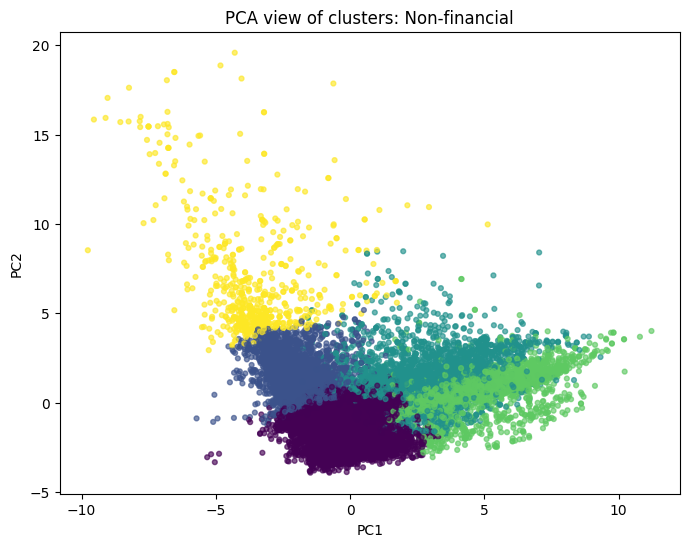

Explained variance: [0.35153854 0.25049335]


In [55]:
if not clustered_panel.empty:
    first_segment = clustered_panel[SEGMENT_COL].value_counts().index[0]
    g = clustered_panel[clustered_panel[SEGMENT_COL] == first_segment].copy()
    features = get_features_for_segment(first_segment, SEGMENT_COL)
    features = [f for f in features if f in g.columns and g[f].notna().mean() >= 0.50]

    prep = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ])
    Xp = prep.fit_transform(g[features])
    pca = PCA(n_components=2, random_state=42)
    pcs = pca.fit_transform(Xp)

    plt.figure(figsize=(8, 6))
    plt.scatter(pcs[:, 0], pcs[:, 1], c=g["cluster"], s=12, alpha=0.65)
    plt.title(f"PCA view of clusters: {first_segment}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

    print("Explained variance:", pca.explained_variance_ratio_)

## 9. Compare 5 clusters vs alternatives

We want 5 clusters for business interpretability, but we should still test whether the data screams for fewer/more. Use this as governance, not as an automatic decision.

In [31]:
def evaluate_k_range(df, segment_name, segment_col, k_values=range(2, 9)):
    features = get_features_for_segment(segment_name, segment_col)
    use = df[df[segment_col] == segment_name].copy()
    availability = use[features].notna().mean().sort_values(ascending=False)
    features = availability[availability >= 0.50].index.tolist()
    if len(use) < 500 or len(features) < 4:
        return pd.DataFrame()

    prep = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ])
    X = prep.fit_transform(use[features])

    rows = []
    for k in k_values:
        labels = KMeans(n_clusters=k, n_init=500, random_state=42).fit_predict(X)
        rows.append({
            "segment": segment_name,
            "k": k,
            "rows": len(use),
            "features": len(features),
            "silhouette": silhouette_score(X, labels),
            "calinski_harabasz": calinski_harabasz_score(X, labels),
            "davies_bouldin": davies_bouldin_score(X, labels),
        })
    return pd.DataFrame(rows)

k_tests = []
for segment_name in sorted(model_df[SEGMENT_COL].dropna().unique()):
    kt = evaluate_k_range(model_df, segment_name, SEGMENT_COL)
    if not kt.empty:
        k_tests.append(kt)

k_tests = pd.concat(k_tests, ignore_index=True) if k_tests else pd.DataFrame()
k_tests



,segment,k,rows,features,silhouette,calinski_harabasz,davies_bouldin
0,Financial,2,9036,7,0.820839,4477.873852,1.000229
1,Financial,3,9036,7,0.812572,5806.678862,0.650099
2,Financial,4,9036,7,0.738175,5601.088900,0.698447
3,Financial,5,9036,7,0.739948,5352.439353,0.702834
4,Financial,6,9036,7,0.601409,5357.853364,0.825282
5,Financial,7,9036,7,0.540533,5119.018934,0.846477
6,Financial,8,9036,7,0.548529,4930.523920,0.929560
7,Non-financial,2,22522,10,0.386845,7662.354143,1.382843
8,Non-financial,3,22522,10,0.299397,7096.000775,1.264132
9,Non-financial,4,22522,10,0.312125,6816.725074,1.228821


## 10. Save outputs

These are the handoff files for review and downstream modeling.

In [ ]:
OUTPUT_DIR = "credit_clustering_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

panel.to_parquet(os.path.join(OUTPUT_DIR, "issuer_year_feature_panel.parquet"), index=False)
clustered_panel.to_parquet(os.path.join(OUTPUT_DIR, f"clustered_panel_by_{SEGMENT_COL}.parquet"), index=False)
cluster_profile_ranked.to_csv(os.path.join(OUTPUT_DIR, f"cluster_profile_by_{SEGMENT_COL}.csv"), index=False)
metrics_df.to_csv(os.path.join(OUTPUT_DIR, f"cluster_metrics_by_{SEGMENT_COL}.csv"), index=False)
k_tests.to_csv(os.path.join(OUTPUT_DIR, f"cluster_k_tests_by_{SEGMENT_COL}.csv"), index=False)

print("Saved outputs to", OUTPUT_DIR)

## Recommended next move

Run this twice:

1. `SEGMENT_COL = "financial_flag"`
2. `SEGMENT_COL = "major_sector"`

Then compare:

- cluster sizes,
- silhouette / Davies-Bouldin,
- interpretability of medians,
- whether financials behave better when isolated.

The expected outcome is likely:

- financials separate,
- non-financials clustered by major sector where sample size is large enough,
- small SIC groups merged into a broader non-financial bucket.

In [56]:
MODEL_DIR = PROJECT_ROOT / "saved_models"
MODEL_DIR.mkdir(exist_ok=True)

credit_cluster_artifact = {
    "model_name": "nonfinancial_credit_kmeans_k5",
    "segment": "Non-financial",
    "pipeline": segment_artifacts["Non-financial"]["pipeline"],
    "feature_cols": segment_artifacts["Non-financial"]["feature_cols"],
    "cluster_labels": {
        0: "Balanced operating issuers",
        1: "Large leveraged cash generators",
        2: "Small cash-burning loss-makers",
        3: "Cash-rich low-leverage loss-makers",
        4: "Near-default / distressed capital structure",
    },
    "risk_rank": {
        0: 1,
        1: 2,
        3: 3,
        2: 4,
        4: 5,
    },
    "winsor_caps": winsor_caps,
    "training_rows": len(clustered_panel[clustered_panel["financial_flag"] == "Non-financial"]),
    "notes": "KMeans++ k=5 model trained on cleaned non-financial EDGAR issuer-years.",
}

joblib.dump(
    credit_cluster_artifact,
    MODEL_DIR / "nonfinancial_credit_kmeans_k5.joblib"
)

print("Saved model to:", MODEL_DIR / "nonfinancial_credit_kmeans_k5.joblib")

Saved model to: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\Machine_learning\saved_models\nonfinancial_credit_kmeans_k5.joblib
